In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import sys, os

import cartopy
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from matplotlib.gridspec import GridSpec

# cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('../modules')
from plotter import draw_basemap, plot_terrain
import customcmaps as ccmap

In [2]:
path_to_out = '../out/'
path_to_figs = '../figs/'

In [3]:

fname = os.path.join(path_to_out, "AR_fraction_extreme_SWE_SNOTEL.csv")
df = pd.read_csv(fname)
df

,station,latitude,longitude,elevation,lat,lev,ens,lon,AR_fraction_extreme_SWE
0,317:WY:SNTL,41.05402,-107.26674,7460.0,41.00,0.0,1.0,-107.25,42.083675
1,335:CO:SNTL,39.80364,-105.77786,11300.0,39.75,0.0,1.0,-105.75,33.266291
2,342:WY:SNTL,42.64580,-109.25965,9100.0,42.75,0.0,1.0,-109.25,56.742815
3,345:CO:SNTL,39.76458,-107.35628,10950.0,39.75,0.0,1.0,-107.25,63.401543
4,348:UT:SNTL,38.67990,-111.59765,9420.0,38.75,0.0,1.0,-111.50,49.337121
...,...,...,...,...,...,...,...,...,...
85,859:WY:SNTL,41.00368,-106.90795,8950.0,41.00,0.0,1.0,-107.00,41.254969
86,864:UT:SNTL,39.96450,-110.98845,8620.0,40.00,0.0,1.0,-111.00,60.671642
87,543:UT:SNTL,39.89166,-110.74604,9170.0,40.00,0.0,1.0,-110.75,68.237854
88,869:CO:SNTL,40.34734,-106.09520,9520.0,40.25,0.0,1.0,-106.00,39.744452


In [11]:
df.sort_values(by='AR_fraction_extreme_SWE')

,station,latitude,longitude,elevation,lat,lev,ens,lon,AR_fraction_extreme_SWE
30,522:UT:SNTL,40.90663,-109.96287,9120.0,41.00,0.0,1.0,-110.00,20.276100
31,528:UT:SNTL,40.92167,-110.18623,9170.0,41.00,0.0,1.0,-110.25,25.761773
29,521:UT:SNTL,40.95009,-110.48419,9510.0,41.00,0.0,1.0,-110.50,28.709918
1,335:CO:SNTL,39.80364,-105.77786,11300.0,39.75,0.0,1.0,-105.75,33.266291
8,378:CO:SNTL,39.87504,-107.59902,9290.0,40.00,0.0,1.0,-107.50,35.369775
...,...,...,...,...,...,...,...,...,...
64,720:UT:SNTL,40.54875,-110.69292,7880.0,40.50,0.0,1.0,-110.75,74.614472
84,843:CO:SNTL,37.48524,-107.50748,10740.0,37.50,0.0,1.0,-107.50,75.143560
82,840:CO:SNTL,37.48563,-106.83528,10140.0,37.50,0.0,1.0,-106.75,75.403123
72,780:CO:SNTL,37.69883,-107.77841,10660.0,37.75,0.0,1.0,-107.75,78.715919


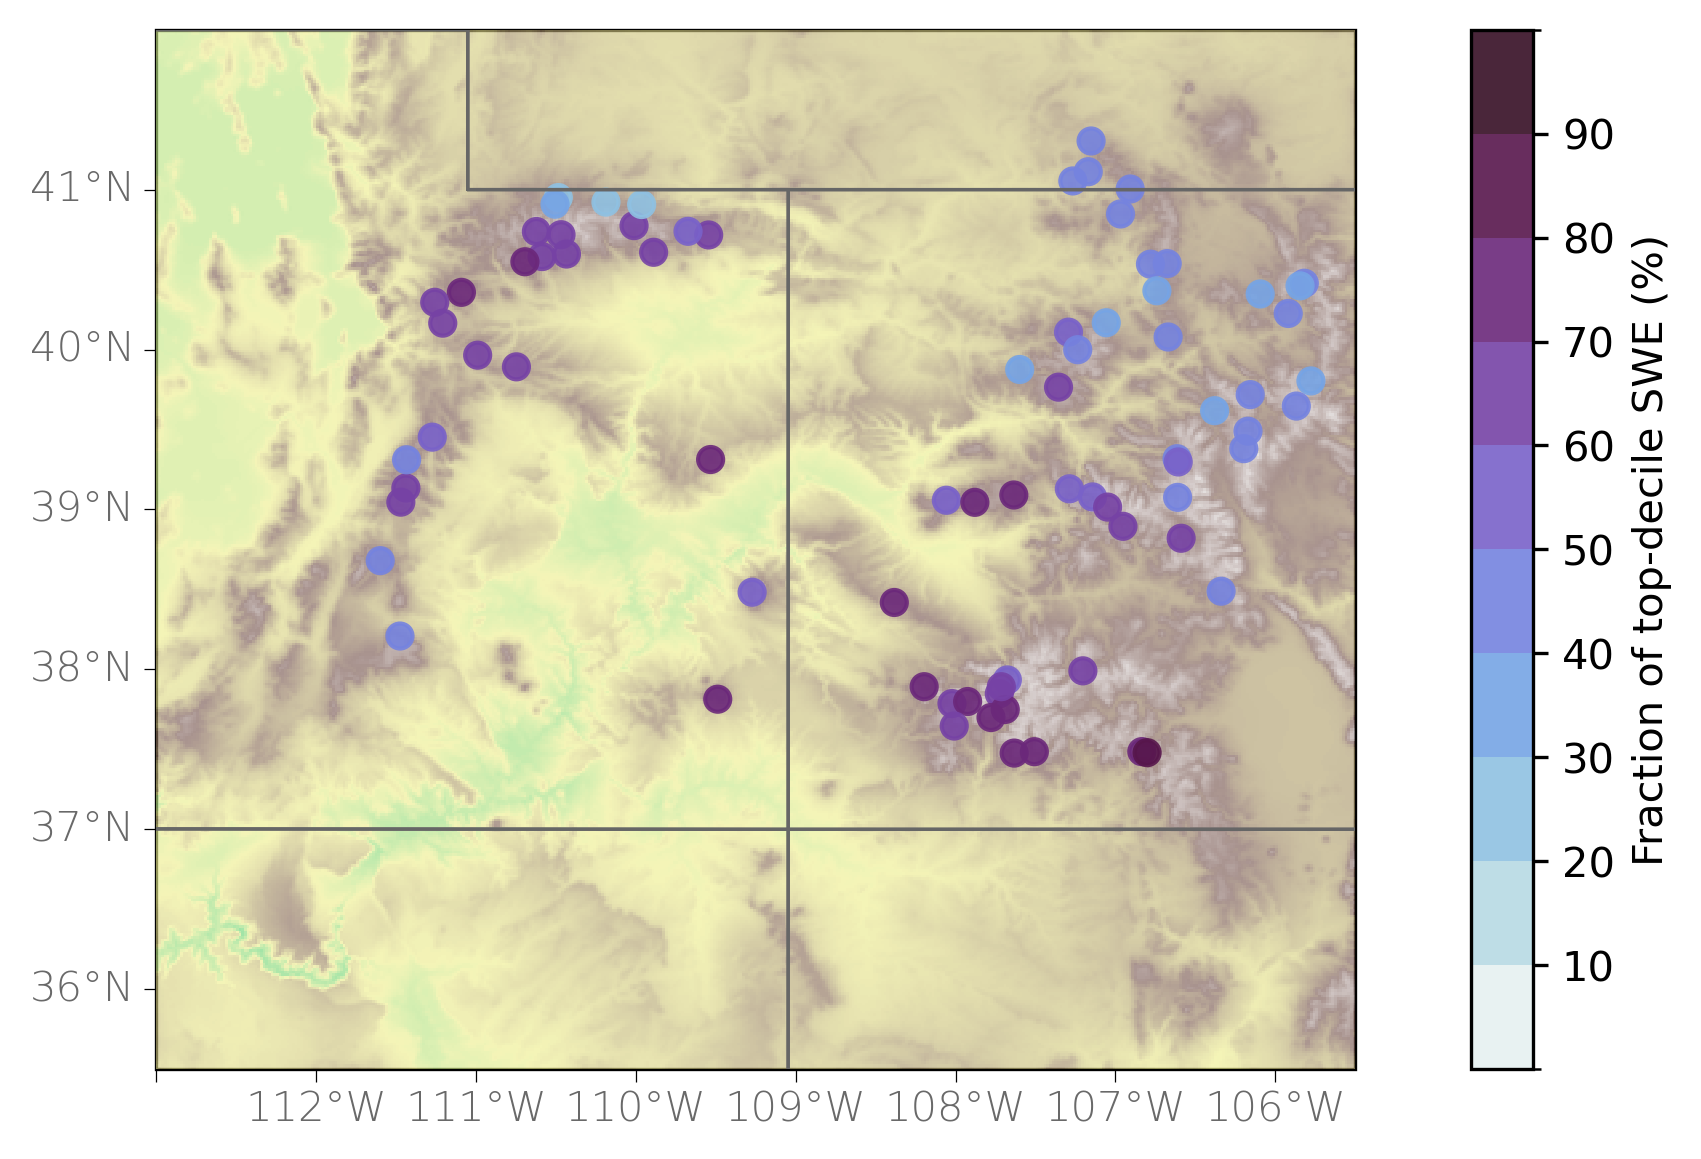

In [10]:
# Set up projection
datacrs = ccrs.PlateCarree()  ## the projection the data is in
mapcrs = ccrs.PlateCarree() ## the projection you want your map displayed in

# Set tick/grid locations
ext1 = [-113, -105.5, 35.5, 42.] # extent of CO
dx = np.arange(-113., -105.,1)
dy = np.arange(36, 42,1)

# Create figure
fig = plt.figure(figsize=(6., 4.5))
fig.dpi = 300
fname = path_to_figs + 'AR_contribution_SNOTEL'
fmt = 'png'

# Grid layout
gs = GridSpec(
    1,
    2,
    height_ratios=[1],
    width_ratios=[1, 0.05],
    wspace=0.15,
    hspace=0.03,
)

# Add color bar axis
cbax = fig.add_subplot(gs[0,-1])

## Add axis for plot
ax = fig.add_subplot(gs[0,0], projection=mapcrs)
ax = draw_basemap(ax, extent=ext1, xticks=dx, yticks=dy,left_lats=True, right_lats=False, bottom_lons=True, mask_ocean=False, coastline=False)

# topo with gray shading
cs = plot_terrain(ax, ext1, vmax=4400, greyscale=False)

# add choropleth watershed fraction
cbarticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
cmap, norm, bnds = ccmap.cmap_segmented(cmo.dense, np.arange(0, 110, 10))
col_name = 'AR_fraction_extreme_SWE'
sc = ax.scatter(
    df['longitude'],
    df['latitude'],
    c=df[col_name],
    cmap=cmap,
    norm=norm,
    alpha=0.9,
    transform=datacrs,   # <-- critical for Cartopy
    zorder=101,
)

cbar = plt.colorbar(sc, cax=cbax)
cbar.set_label("Fraction of top-decile SWE (%)")
cbar.set_ticks(cbarticks)

ax.add_feature(cfeature.STATES, edgecolor='0.4', linewidth=0.8, zorder=199)

        
fig.savefig('%s.%s' %(fname, fmt), bbox_inches='tight', dpi=fig.dpi)